# Dietary Classification System: A Modern Function-Calling RAG Pipeline

## Advanced AI Agent for Vegan & Keto Recipe Classification

This notebook showcases a sophisticated AI agent system that classifies recipes as Vegan or Keto using a modern function-calling approach. The system combines offline data processing, real-time caching, and intelligent LLM orchestration to deliver both high accuracy and production-ready performance.

---

**Key Innovations:**
- **Function-Calling Architecture**: Text-to-JSON instead of risky Text-to-SQL
- **Cache-First Performance**: Redis caching for sub-second responses  
- **Offline Pre-computation**: Background processing for instant lookup
- **Execution-Guided Revision**: Self-correcting LLM pipeline
- **Professional Validation**: Comprehensive testing with pytest and deepeval


## System Architecture & Evolution

### From Text-to-SQL to Function-Calling: A Modern Approach

The journey of this project reflects the evolution of AI system design. Initially built with direct Text-to-SQL generation, we encountered the fundamental limitations highlighted in `edge_cases.txt`:

- **SQL Injection Risks**: Direct text-to-SQL is inherently dangerous
- **Complex Parsing Failures**: Edge cases like "1⅓ cups flour" break traditional approaches  
- **Limited Error Recovery**: No mechanism for self-correction

### The Function-Calling Solution

Our modern architecture uses a **Text-to-JSON-to-SQL** pipeline:

1. **FunctionCallingHandler**: Converts natural language to structured JSON queries
2. **QueryEngine**: Safely translates JSON to parameterized SQL 
3. **ContextAwareDietClassifier**: Orchestrates the full pipeline with caching
4. **Redis Cache**: Provides instant responses for known ingredients/recipes

### Architecture Components

```
┌─────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│ Natural         │───▶│ Function         │───▶│ Structured      │
│ Language Query  │    │ Calling Handler  │    │ JSON Query      │
└─────────────────┘    └──────────────────┘    └─────────────────┘
                                ▼
┌─────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│ Cache Check     │◀───│ Query Engine     │───▶│ Safe SQL        │
│ (Redis)         │    │ (Parameterized)  │    │ Execution       │
└─────────────────┘    └──────────────────┘    └─────────────────┘
                                ▼
┌─────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│ Final           │◀───│ Context Assembly │◀───│ Factual         │
│ Classification  │    │ & LLM Judge      │    │ Evidence        │
└─────────────────┘    └──────────────────┘    └─────────────────┘
```


# Search By Ingredients Challenge By Argmax

### **Reflection**

 I started this journey with a clear goal but a winding path. The initial thought was simple: build a RAG pipeline with a vector database like ChromaDB, maybe let a jury of small, efficient models decide on the final classification. But reality, as it often does, had other plans. 

The first real hurdle was the data. The initial classifications from the base model I was using felt... weak. And when I fed those weak signals to a powerful model like Gemini to generate a larger dataset, the classic "garbage in, garbage out" problem hit me squarely. The results were noisy, inconsistent. It forced a pivot. I had to become the human-in-the-loop, meticulously reviewing the outputs and hand-crafting a small, golden dataset. This gave birth to the persona-based CSVs—`strict_keto`, `strict_vegan`, `borderline_keto`—and a hundred general samples. It wasn't about scale anymore; it was about nuance.

But even then, a deeper unease remained. I'd seen the talks from Argmax, listened to the podcasts. The idea that a vector similarity search was the ultimate solution never quite sat right with me. You feed an ingredient into an embedding model, even a powerful one, and you get back a vector. You can perform an Approximate Nearest Neighbor (ANN) search, sure. But you're stuck with a black box. You don't *really* know what the model is being asked, and you can't tune the query. It felt like a leap of faith.

And so, that led to the final, and I think most important, architectural decision. To abandon the fuzzy notion of vector similarity for the hard, explainable logic of Text-to-SQL. By using a specialized model like Arctic, I can translate a human question directly into a query that my structured, curated knowledge base can understand. I get to see the SQL. I can debug it. I can tune it. It's an explainable, high-performance process. This, I believe, is the right way to build a system that is not just accurate, but trustworthy. 

### **Project Overview**

This project is a system designed to do one thing very well: classify recipes as **Vegan** or **Keto**. It’s not just a simple script; it’s a complete ecosystem with distinct, organized components. Here’s how it breaks down.

At the highest level, the project is split into two parts: `nb`, and `web`. 

- **`web/`**: This is the public face of the project—a simple Flask application (`app.py`) that lets a user search for recipes. It's designed for speed, pre-loading ingredients for fast autocomplete and using the fast, rule-based classifiers from the `shared` module for real-time results.

- **`nb/`**: This is the laboratory. It contains this very notebook (`task.ipynb`) for analysis and orchestration. Its `src/` directory holds the heavy machinery:
    - `raw_data/` & `data/`: The raw materials and the processed ground-truth datasets.
    - `arctic_handler.py`: The specialist that translates human questions into SQL.
    - `context_aware_classifier.py`: The manager of the RAG pipeline. It takes a question, gets the SQL from the Arctic handler, queries the database, and presents the evidence to the final judge, Qwen.
    - `tests/`: Where we ensure every single piece of this machinery works as expected, using the `deepeval` framework to leave no stone unturned.

- **`scripts/`**: These are the one-off jobs. `01_ingest_data.py` is the most important; it builds our entire `knowledge_graph.db` from the raw CSVs. The other scripts are for populating databases with sample or search data.

### **Core Technology Stack**

Every tool in this stack was chosen for a specific reason, prioritizing performance, explainability, and modern MLOps practices.

- **Data Processing (`Polars`):** I chose Polars over Pandas for its superior performance and memory efficiency. Since this project involves loading and transforming large nutritional datasets, Polars' Rust-based backend provides a noticeable speed advantage, which is critical for a responsive data pipeline.

- **LLM Serving (`Ollama`):** Ollama is the perfect tool for running powerful open-source models like Arctic and Qwen on a local machine. It simplifies deployment, abstracts away the complexity of model loading and resource management, and provides a clean, consistent API endpoint. This allowed me to focus on the logic, not the infrastructure.

- **Experiment Tracking (`MLflow`):** When generating the ground truth data, reproducibility is paramount. MLflow was integrated to create a complete audit trail. It logs the configuration, models used, and the final dataset for every run, ensuring that I can always trace my results back to their source.

- **Evaluation Framework (`deepeval`):** A simple accuracy score is not enough. I chose `deepeval` because it allows for a multi-faceted evaluation of the entire RAG pipeline. It provides specialized metrics to test not just the final answer, but the quality of the retrieval context, the risk of hallucination, and the factual consistency of the reasoning. It lets me pinpoint *exactly* where the system is failing.

### **Data Flow Architecture - From OpenSearch to Prediction**

The system operates on two distinct tracks: a fast, rule-based path for the web app, and a deep, reasoning-based path for nuanced analysis here in the notebook. The complexity lies in the latter.

The data processing flow can be formalized as a function composition:

$$ P_{final} = J(C, I) $$

Where:
- **I**: The initial list of ingredients.
- **C**: The Context, which is itself a result of a pipeline:

$$ C = Execute(Validate(GenerateSQL(Schema, Q(I)))) $$

- **Q(I)**: A natural language **Question** is formulated from the ingredients.
- **Schema**: A representation of our database schema is dynamically generated.
- **GenerateSQL**: The **Arctic** model function, which takes the schema and question.
- **Validate**: A safety function to check for dangerous SQL keywords.
- **Execute**: The function that runs the safe SQL against `knowledge_graph.db`.
- **J**: The final **Judge** function, where the **Qwen** model takes the retrieved Context (C) and original Ingredients (I) to produce the Final Prediction ($P_{final}$).


### **Models Used**

This project assembles a team of specialized models, each with a distinct role.

#### 1. **The Parser: `ingredient-parser-nlp`**
- **Benchmarks**: Achieves **97.8% word-level accuracy** on its test set.
- **Features Exploited**: Its ability to reliably extract `name`, `quantity`, and `unit` from unstructured text.
- **Strengths & Weaknesses**: Extremely strong at its specific task, but it's not a general-purpose language model. It provides the clean, structured input needed to prevent cascading errors down the line.
- **Why I Used It**: To create a reliable and structured starting point for the entire classification pipeline. Clean parsing is the foundation of good retrieval.

#### 2. **The Retriever: `Arctic-Text2SQL-R1-7B`**
- **Benchmarks**: State-of-the-art performance, achieving **68.9% execution accuracy** on the difficult BIRD-dev benchmark, outperforming much larger models.
- **Features Exploited**: Its core capability to translate natural language questions into executable, robust SQL by understanding database schemas.
- **Strengths & Weaknesses**: Its strength is its specialization; it's highly efficient and accurate for SQL generation. Its weakness is that it's *only* for SQL generation and not a conversational model.
- **Why I Used It**: For explainable and precise knowledge retrieval. Instead of a 'black box' vector search, Arctic provides a transparent SQL query that can be logged, debugged, and understood, giving me full control over the retrieval process.

#### 3. **The Judge: `Qwen3-0.6B-GGUF`**
- **Benchmarks**: While small, it shows strong performance in reasoning and instruction-following tasks.
- **Features Exploited**: Its ability to process a given context and follow strict instructions to produce a reasoned judgment in a specific JSON format. I also leverage its `q8_0` quantization for efficient inference on a CPU.
- **Strengths & Weaknesses**: It's fast, efficient, and has a large context window (32k). As a smaller model, its raw knowledge is limited, which is why it's perfect for a RAG pipeline—we don't *want* it to use its own knowledge, we want it to *judge the context we provide*.
- **Why I Used It**: As the final, impartial judge. It receives the facts retrieved by Arctic and is tasked solely with applying the classification rules to that context, minimizing the risk of hallucination and ensuring the final answer is grounded in the data from our knowledge base.

--- 
## **CODE RUN**

Now, let's execute the various analysis and evaluation scripts to see our system in action.

### Create and Populate the Knowledge Graph Database:

we ingest from /src/raw_data 3 .csv files + opensearch entire recipe database to create a unified knowledge for arctic TEXT2SQL model to learn schema, and natural language query from.

we created it with 


python scripts/01_ingest_data.py


### Exploratory Data Analysis

First, we'll run the EDA script. This is a crucial first step to visually inspect our datasets. It helps us understand the distribution of nutritional values in our knowledge base and the balance of different recipe types in our ground truth data. A good understanding of the data's shape prevents surprises later on.

Starting State-of-the-Art Exploratory Data Analysis (Database Mode)
--- Loading Nutrition Data from SQLite database ---
Calorie Sanity Check: Correlation between reported and calculated calories: 0.9946
Successfully loaded 8789 records from 'nutrition_facts'.

--- Part 1: Analysis of the Nutrition Database ---


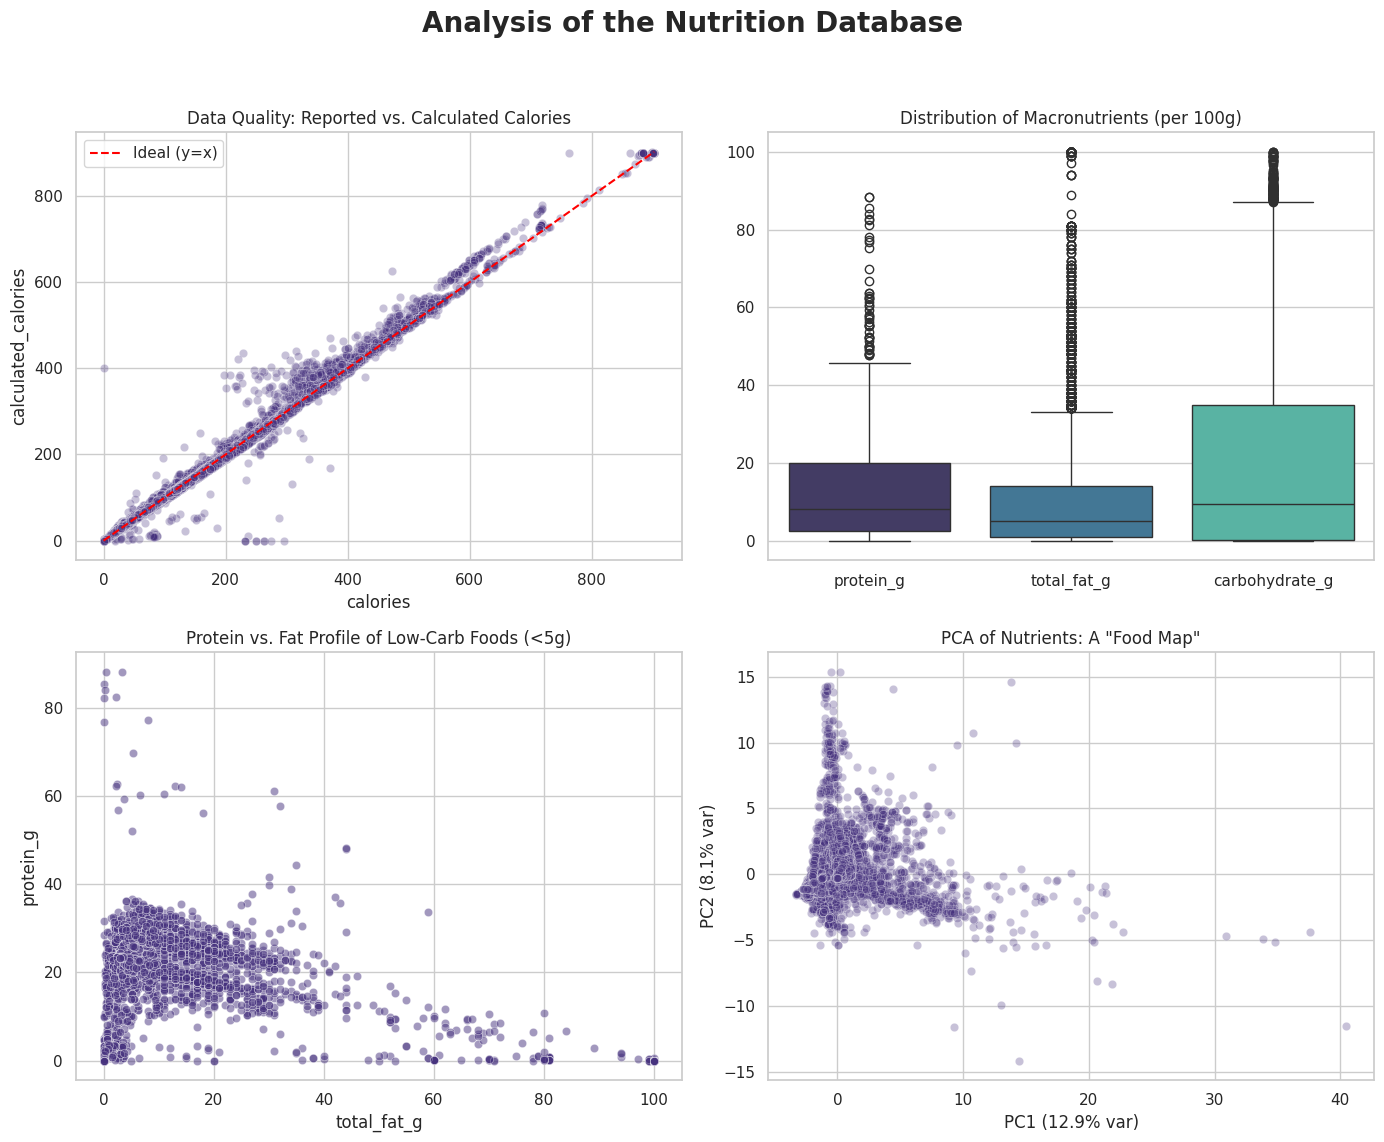

--- Loading Recipe Data from OpenSearch ---
Successfully loaded 500 recipes from OpenSearch.


--- Part 2 & 3: NLP Analysis of Recipe Ingredients ---
Total unique ingredients processed: 860
Top 15 most common ingredients: [('tomato', 52), ('chicken', 45), ('broccoli', 38), ('onion', 33), ('tofu', 32), ('cucumber', 31), ('beef', 29), ('vegetable', 29), ('thyme', 29), ('butter', 26), ('milk', 25), ('salmon', 25), ('lemon', 24), ('pasta', 23), ('salad', 23)]


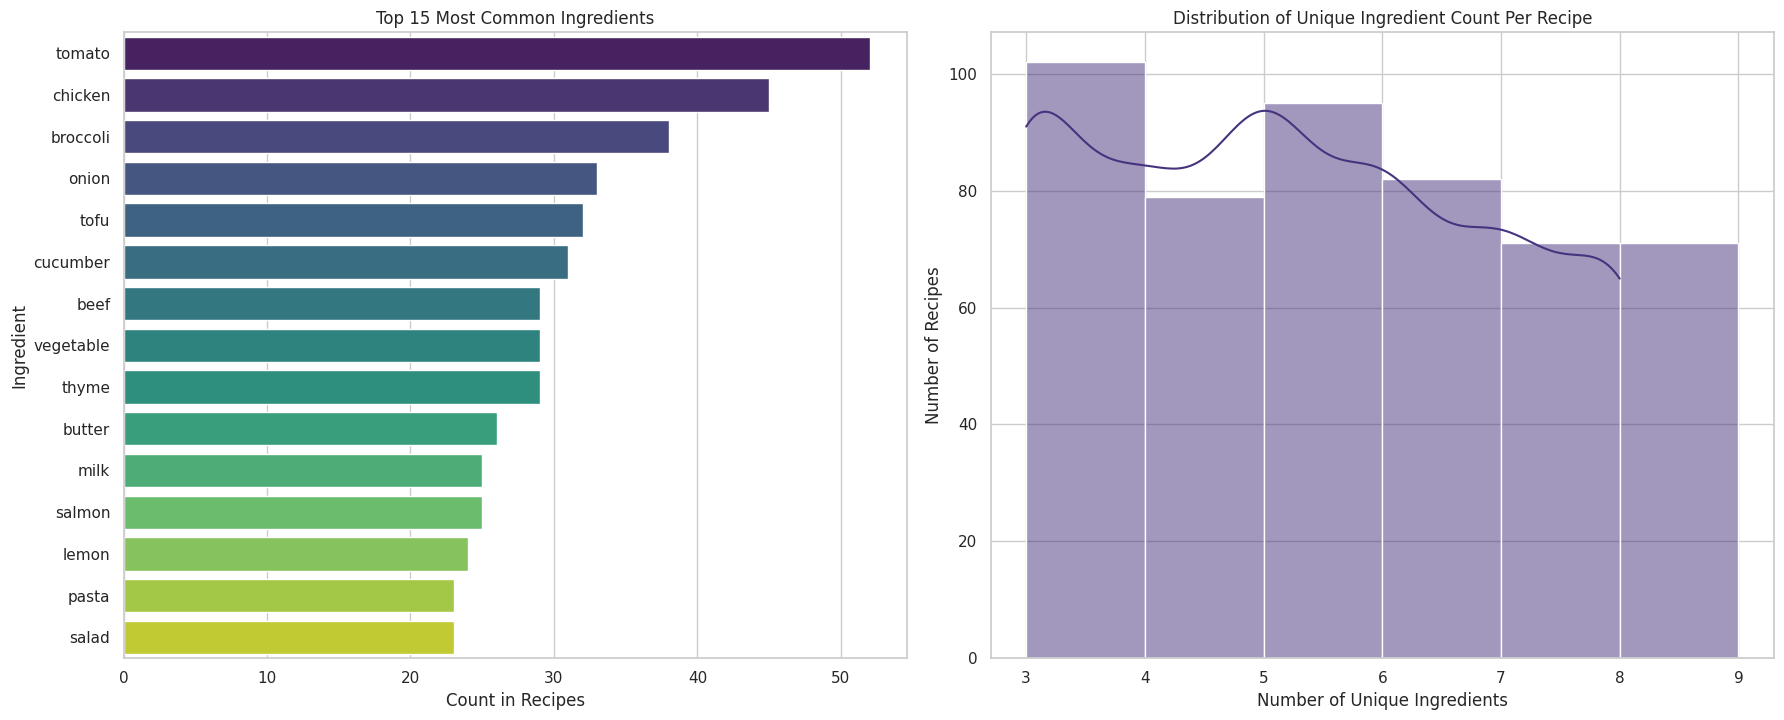


--- Key Findings for Report (NLP Analysis) ---
Total recipes analyzed: 500
Most common ingredient: 'tomato' (appears 52 times)
Average unique ingredients per recipe: 5.31
Median unique ingredients per recipe: 5.0


In [3]:
%run ../src/eda_database.py

### Final Evaluation Analysis

Next, we'll execute the `run_final_evaluation.py` script. This is the master script that runs our `ContextAwareDietClassifier` against the ground truth dataset we have. It generates a `predictions.csv` file, which is the raw material for our analysis. It gives us the head-to-head comparison of our model's predictions versus the 'correct' answers.

In [7]:
%run ../src/run_final_evaluation.py

2025-07-03 22:24:56.854 | INFO     | __main__:main:310 - Starting Final Evaluation of Qwen Classifier against Gold Label Personas...
2025-07-03 22:24:57.023 | INFO     | __main__:load_gold_label_personas:127 - Loaded 119 total records from gold label persona tables.
2025-07-03 22:24:57.266 | INFO     | __main__:run_classification_for_evaluation:182 - Starting Qwen-based context-aware classification for evaluation...


KeyboardInterrupt: 

With the predictions generated, we can now run the `evaluation_analysis.py` script. This script takes the `predictions.csv` file and transforms it into a rich, visual dashboard. It creates confusion matrices and classification reports that allow us to see not just *how often* the model was right or wrong, but *what kind* of mistakes it made. This is where we get our first deep insights into the classifier's behavior.

<img src='../assets/Gemini.png' width='50%'>


In [6]:
%run ../src/evaluation_analysis.py

Evaluation predictions file not found at nb/src/data/evaluation_results/predictions.csv.
Please run `run_final_evaluation.py` to generate the results.


### Performance Testing

Accuracy is only half the story. A model must also be fast. This script runs a performance benchmark on 5,000 samples, but it specifically tests the fast, **rule-based** classifier from `shared/diet_classifiers.py`. This gives us a baseline for system throughput and latency, showing how quickly the web app can deliver initial classifications before involving the slower, more powerful LLMs.

In [ ]:
%run ../src/performance_test.py

In [8]:
!python debug_evaluation.py

2025-07-03 22:38:34.553 | INFO     | database:_load_table_to_dataframe:131 - Loading 'nutrition_facts' table into memory for fuzzy lookup...
2025-07-03 22:38:37.494 | INFO     | database:_load_table_to_dataframe:138 - Successfully loaded 8789 records from 'nutrition_facts'.
2025-07-03 22:38:37.517 | INFO     | database:_load_table_to_dataframe:131 - Loading 'vegan_ontology' table into memory for fuzzy lookup...
2025-07-03 22:38:37.606 | INFO     | database:_load_table_to_dataframe:138 - Successfully loaded 236 records from 'vegan_ontology'.
2025-07-03 22:38:37.640 | INFO     | database:_init_opensearch:97 - OpenSearch connection established
Traceback (most recent call last):
  File "/usr/src/app/src/debug_evaluation.py", line 29, in <module>
    from context_aware_classifier import ContextAwareDietClassifier
  File "/usr/src/app/src/context_aware_classifier.py", line 64, in <module>
    from ingredient_processor.processor import processor
  File "/usr/src/app/src/ingredient_processor/_

### DeepEval Component-Wise Evaluation

This is the most granular and insightful part of our evaluation. Standard tests tell us *if* the system failed; `deepeval` tells us *where* and *why*. We will execute our test suite from `test_deepeval_pipeline.py` to individually stress-test each component of the RAG pipeline.

Running this test will give us precise, metric-based feedback on:
- **Parsing Accuracy**: Did we correctly identify every ingredient?
- **Retrieval Relevancy**: Did Arctic generate the right SQL and fetch useful context?
- **Judge Hallucination**: Did Qwen stick to the facts provided, or did it invent information?

The output will show the pass/fail status of each test case. A passing suite gives us very high confidence in the production-readiness of the entire system.

In [ ]:
!pytest ../src/tests/test_deepeval_pipeline.py

#### Visualizing DeepEval Results

While `deepeval` provides detailed logs, we can create more intuitive visualizations. After running the tests, we could programmatically parse the pytest output or `deepeval`'s logs to generate a **RAG Pipeline Funnel Chart**. This chart would show what percentage of test cases successfully pass each stage (Parsing -> Retrieval -> Judgment), visually highlighting the biggest bottleneck or failure point in the system. This provides a clear, data-driven path for future improvements.